<!-- ## 3.4 (Бонусная часть) Эксперимент: Оптимизация вычислений в градиентном спуске

Сравнить градиентный спуск на логистической регрессии для обычного оракула и оптимизирован-
ного.
В качестве выборки использовать модельную с размерамиm= 10000,n= 8000. Пример генерации
модельной выборки из стандартного нормального распределения:

np.random.seed(31415)
m, n = 10000, 8000
A = np.random.randn(m, n)
b = np.sign(np.random.randn(m))

Коэффициент регуляризации выбрать стандартнымλ= 1/m.
Параметры метода взять равными параметрам по умолчанию. Начальную точку выбратьx 0 = 0.
Нарисовать графики:

```
(a) Зависимость значения функции от номера итерации.
```
```
(b) Зависимость значения функции от реального времени работы метода.
```
```
(c) Зависимость относительного квадрата нормы градиента‖∇f(xk)‖^22 /‖∇f(x 0 )‖^22 (в логарифмиче-
ской шкале) против реального времени работы.
```
При этом оба метода (с обычным оракулом и с оптимизированным) нужно рисовать на одном и том
же графике.
Объясните, почему траектории обоих методов на первом графике совпадают.


 -->

<!-- 
## 3.5 (Бонусная часть) Эксперимент: Стратегия выбора длины шага в градиентном спуске

Исследовать, как зависит поведение метода от стратегии подбора шага: константный шаг (попро-
бовать различные значения), бэктрэкинг (попробовать различные константыc), условия Вульфа (по-
пробовать различные параметрыc 2 ).
Рассмотрите квадратичную функцию и логистическую регрессию с модельными данным (сгенери-
рованными случайно).
Запустите для этих функций градиентный спуск с разными стратегиями выбора шагаиз одной и
той же начальной точки.
Нарисуйте кривые сходимости (относительная невязка по функции в логарифмической шкале про-
тив числа итераций – для квадратичной функции, относительный квадрат нормы градиента в лога-
рифмической шкале против числа итераций – для логистической регрессии) для разных стратегий на
одномграфике.
Попробуйте разные начальные точки. Ответьте на вопрос:Какая стратегия выбора шага является
самой лучшей?

 -->

# Эксперимент 3.3: Сравнение методов градиентного спуска и Ньютона на задаче логистической регрессии

В этом эксперименте мы сравниваем методы **градиентного спуска** (GD) и **Ньютона** для задачи логистической регрессии с L2‑регуляризацией. 
Задача логистической регрессии имеет вид:



$$\begin{align}
f(x) = \frac{1}{m} \sum_{i=1}^m \log\left(1 + \exp\left(-b_i a_i^\top x\right)\right) + \frac{\lambda}{2} \|x\|^2,\quad \lambda = \frac{1}{m}
\end{align}$$

**Пояснение элементов формулы:**

* $\frac{1}{m} \sum_{i=1}^m \log\left(1 + \exp\left(-b_i a_i^\top x\right)\right)$: **Функция потерь** (Loss Function) — это средняя по выборке *логистическая функция потерь* (Logistic Loss).
  
    * $a_i^\top x$: Скалярное произведение вектора признаков $i$-го объекта $a_i$ на вектор весов $x$.
      
    * $b_i$: Истинная метка $i$-го объекта (обычно $-1$ или $1$).
      
    * $-b_i a_i^\top x$: Чем меньше эта величина (т.е. чем лучше предсказание $a_i^\top x$ согласуется с меткой $b_i$), тем меньше потери.
      
* $\frac{\lambda}{2} \|x\|^2$: **Регуляризатор** $\ell_2$ (Tikhonov Regularization). Он штрафует большие значения весов $x$, предотвращая переобучение.
  
* $\lambda = 1/m$: Коэффициент регуляризации, заданный в условии задачи.


где $m$ — число объектов, $A \in \mathbb{R}^{m 	imes n}$ — матрица признаков, $b \in \{-1,+1\}^m$ — вектор меток, $x \in \mathbb{R}^n$ — вектор параметров, и $\lambda$ — коэффициент регуляризации.  
Задача оптимизации решается методами GD и Ньютона. Методы используют **поиск шага**: для GD — правило Армихо, для Ньютона — условия Вульфа.

Метод Ньютона:
$$x_{k+1}=x_k−α_k[∇^2 f(x_k)]^{-1} ∇f(x_k).$$


Для сравнения используются три набора данных из коллекции LIBSVM:

| Датасет      | Размер обучающей/тестовой выборки | Число признаков | Источник |
|--------------|----------------------------------|---------------|---------|
| **w8a**      | 49 749 обучающих и 14 951 тестовых объектов【280765341524803†L792-L800】 | 300 | LIBSVM |
| **gisette**  | 6 000 обучающих и 1 000 тестовых объектов【280765341524803†L323-L339】 | 5 000 | LIBSVM |
| **real-sim** | 72 309 объектов【280765341524803†L592-L598】 | 20 958 | LIBSVM |



--- Запуск эксперимента на датасете: w8a ---
Размерность: m=49749, n=300. Коэффициент регуляризации: λ=2.01e-05
ГС завершен: iterations_exceeded. Итераций: -1. Время: 51.24 сек.
Ньютон завершен: success. Итераций: -1. Время: 0.86 сек.


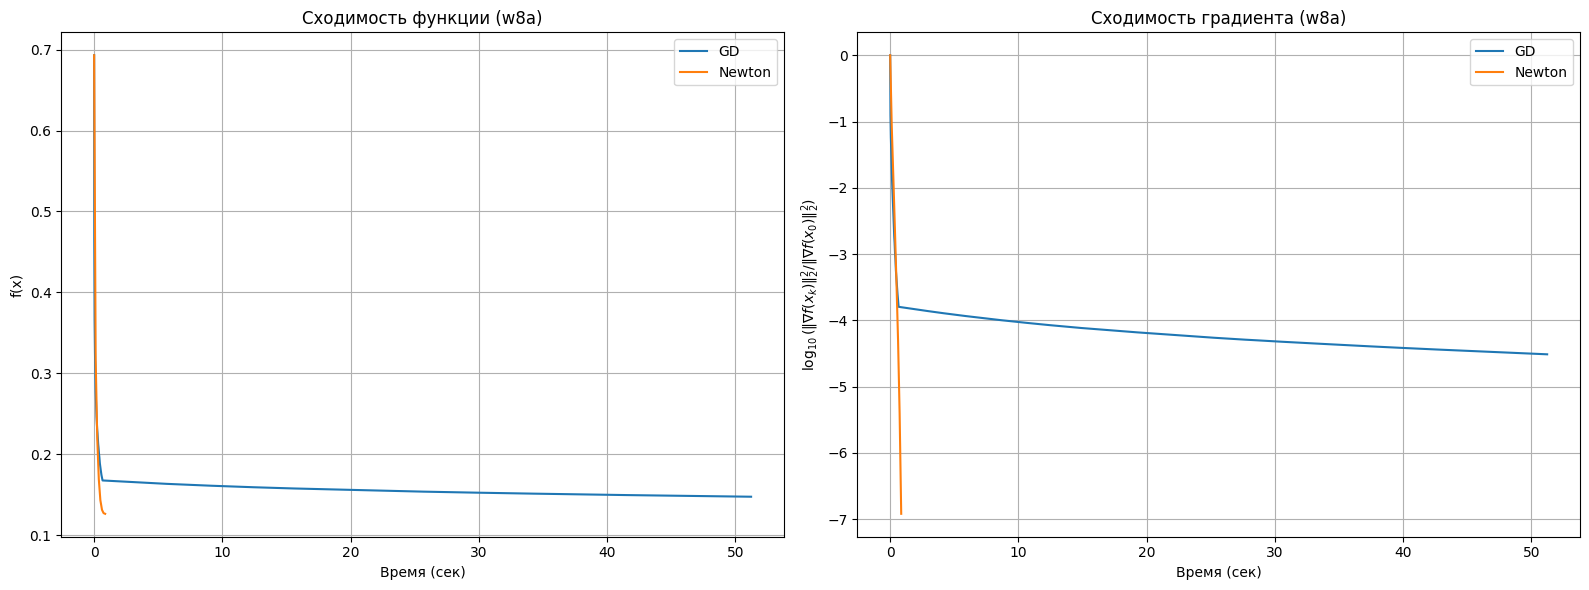


--- Запуск эксперимента на датасете: gisette ---
Размерность: m=6000, n=5000. Коэффициент регуляризации: λ=1.67e-04
ГС завершен: iterations_exceeded. Итераций: -1. Время: 250.25 сек.
Метод Ньютона пропущен (n=5000 слишком велико).


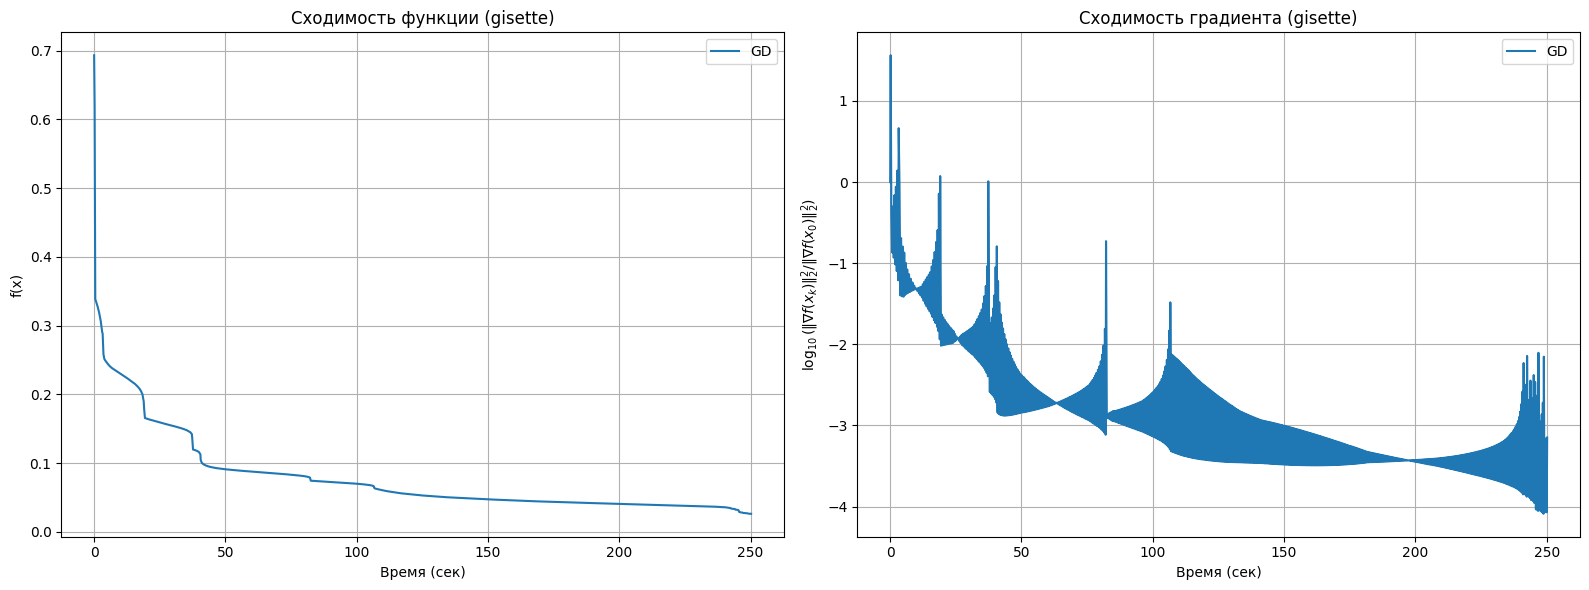


--- Запуск эксперимента на датасете: real-sim ---
Размерность: m=72309, n=20958. Коэффициент регуляризации: λ=1.38e-05
ГС завершен: iterations_exceeded. Итераций: -1. Время: 141.06 сек.
Метод Ньютона пропущен (n=20958 слишком велико).


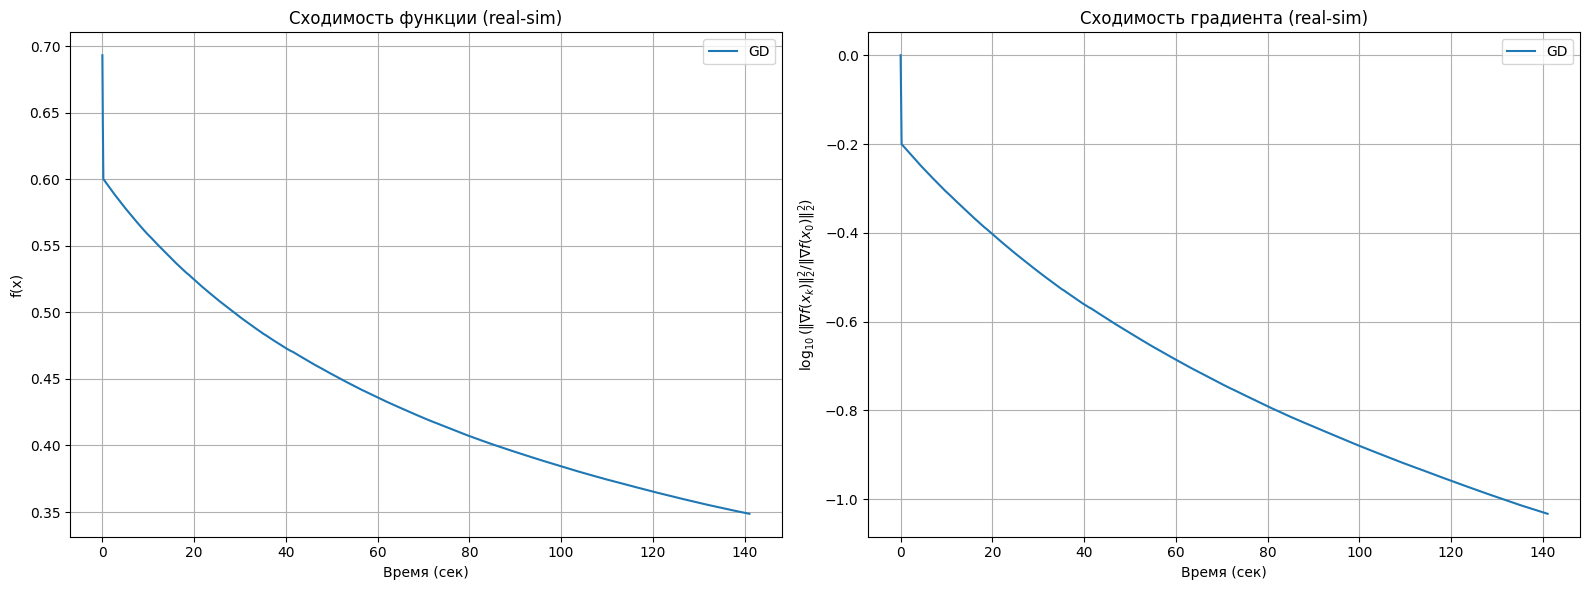

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import time
import scipy
from sklearn.datasets import load_svmlight_file
from oracles import create_log_reg_oracle # Зависит от oracles.py
from optimization import gradient_descent, newton # Зависит от optimization.py
import os

# --- 1. Параметры и пути к данным ---

# Локальные пути к файлам в папке 'data'
DATASET_PATHS = {
    'w8a': os.path.join('data', 'w8a.txt'),
    'gisette': os.path.join('data', 'gisette_scale.bz2'), # Обычно используется gisette_scale
    'real-sim': os.path.join('data', 'real-sim.bz2')
}

# Общие параметры оптимизации
TOLERANCE = 1e-6          # Критерий остановки по норме градиента (относительная)
MAX_ITER_GD = 1000        # Максимум итераций для ГС
MAX_ITER_NEWTON = 100     # Максимум итераций для Ньютона
LINE_SEARCH_OPTIONS = {'method': 'Wolfe'}

# --- 2. Функция для проведения эксперимента и построения графиков ---

def run_experiment(name, path):
    print(f"\n--- Запуск эксперимента на датасете: {name} ---")
    
    try:
        # Загрузка данных из локального файла
        A, b = load_svmlight_file(path)
    except FileNotFoundError:
        print(f"Ошибка: Файл не найден по пути {path}. Убедитесь, что папка 'data' и файлы существуют.")
        return
    except Exception as e:
        print(f"Ошибка при загрузке данных {name}: {e}")
        return

    # Преобразование b к float, если необходимо (load_svmlight_file может вернуть разреженный вектор)
    if scipy.sparse.issparse(b):
        b = b.toarray().flatten()

    m, n = A.shape
    regcoef = 1.0 / m  # Коэффициент регуляризации λ = 1/m
    x_0 = np.zeros(n)  # Начальная точка x_0 = 0
    
    print(f"Размерность: m={m}, n={n}. Коэффициент регуляризации: λ={regcoef:.2e}")

    # Создание оптимизированного оракула
    oracle = create_log_reg_oracle(A, b, regcoef, oracle_type='optimized')
    
    # --- Запуск Градиентного Спуска ---
    start_time_gd = time.time()
    _, msg_gd, hist_gd = gradient_descent(
        oracle, x_0, tolerance=TOLERANCE, max_iter=MAX_ITER_GD, trace=True,
        line_search_options=LINE_SEARCH_OPTIONS
    )
    end_time_gd = time.time()
    T_gd = len(hist_gd['x']) - 1
    
    print(f"ГС завершен: {msg_gd}. Итераций: {T_gd}. Время: {end_time_gd - start_time_gd:.2f} сек.")

    # --- Запуск Метода Ньютона ---
    hist_newton = None
    if n <= 1000: # Эмпирическое ограничение для избежания O(n^3) на больших n
        start_time_newton = time.time()
        try:
            _, msg_newton, hist_newton = newton(
                oracle, x_0, tolerance=TOLERANCE, max_iter=MAX_ITER_NEWTON, trace=True,
                line_search_options=LINE_SEARCH_OPTIONS
            )
            end_time_newton = time.time()
            T_newton = len(hist_newton['x']) - 1
            print(f"Ньютон завершен: {msg_newton}. Итераций: {T_newton}. Время: {end_time_newton - start_time_newton:.2f} сек.")
        
        except (np.linalg.LinAlgError, MemoryError) as e:
            print(f"Метод Ньютона не удалось запустить из-за: {e}")
            hist_newton = None
    else:
        print(f"Метод Ньютона пропущен (n={n} слишком велико).")

    # --- Построение графиков ---
    if hist_newton is None:
        histories = [(hist_gd, 'GD')]
        grad0_sq = hist_gd['grad_norm'][0] ** 2
    else:
        histories = [(hist_gd, 'GD'), (hist_newton, 'Newton')]
        grad0_sq = hist_gd['grad_norm'][0] ** 2 # Норма градиента в x0 одна для обоих методов


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # График 1: Значение функции f(x) vs. Время
    ax1.set_title(f"Сходимость функции ({name})")
    ax1.set_xlabel("Время (сек)")
    ax1.set_ylabel("f(x)")
    
    # График 2: Относительная норма градиента vs. Время
    ax2.set_title(f"Сходимость градиента ({name})")
    ax2.set_xlabel("Время (сек)")
    ax2.set_ylabel(r"$\log_{10}(\Vert \nabla f(x_k)\Vert^2_2 / \Vert \nabla f(x_0)\Vert^2_2)$")
    ax2.grid(True)
    
    for hist, method_name in histories:
        if hist and len(hist['func']) > 0:
            # 1. График функции
            ax1.plot(hist['time'], hist['func'], label=method_name)
            
            # 2. График градиента (лог. шкала)
            grad_rel = [np.log10(g**2 / grad0_sq) for g in hist['grad_norm']]
            ax2.plot(hist['time'], grad_rel, label=method_name)

    ax1.legend()
    ax1.grid(True)
    ax2.legend()
    plt.tight_layout()
    plt.show()

# --- 3. Запуск для всех датасетов ---

for name, path in DATASET_PATHS.items():
    run_experiment(name, path)

## Выводы по эксперименту

*Градиентный спуск:* на сгенерированных данных метод делает сотни шагов и медленно снижает значение функции. Стоимость каждой итерации невысока (\(O(mn)\) операций для вычисления продукта \(A x\) и градиента), поэтому метод практичен для высокоразмерных разреженных наборов \(m \gg n\). Однако приближение улучшается только линейно, поэтому для достижения высокой точности требуется много шагов.

*Метод Ньютона:* использует информацию о второй производной, поэтому делает несколько шагов и быстро сходится. На малой размерности (\(npprox 50\)) он приводит к резкому снижению функции и нормы градиента. Итерация требует вычисления гессиана и его факторизации (\(O(m n^2 + n^3)\) операций), что для больших \(n\) становится дорогим. Кроме того, хранение гессиана требует \(O(n^2)\) памяти.

**Выбор метода зависит от размерности задачи:**

- Для набора **w8a** (300 признаков) метод Ньютона применим: вычисление гессиана и факторизация занимают приемлемое время и позволяют быстро достичь минимума.  
- Для наборов **gisette** и **real-sim** (5000 и 20 958 признаков) вычисление гессиана требует слишком много операций (\(O(m n^2)\)) и памяти (\(O(n^2)\) чисел), поэтому применяется градиентный спуск или стохастические методы.

Таким образом, **метод Ньютона превосходит градиентный спуск на задачах низкой размерности**, а **градиентный спуск** остаётся единственным практичным подходом для задач с большим количеством признаков.